In [3]:
# Standard imports
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import time

In [4]:
sys.path.append(r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/pumat")

from lib.Load_Classes.Popular_Load_Class import PopularPath
from lib.Driver_Classes.Mod_Driver_Setup import DriverModelSetup
from lib.Driver_Classes.Mod_Driver_Model import DriverModel
from lib.general_functions.executing_runs import generate_batch_script, run_batch_script

In [42]:
trx_strain = "TriaxialE1"

load_params = {
    "ninc": 1000,
    "maxiter": 30, # Not sure why this can't be zero (Even though pretty sure incremental driver turns it into 5 anyway), don't have this situation for MCSS
    "dtime"  : 0.001,
    "every"  : 10,
    "ddstran_1": -0.4,
}

# Calc the strain increment
strain_inc = abs(load_params["ddstran_1"]/load_params["ninc"])

# Calc the strain rate
strain_rate = strain_inc/load_params["dtime"]

print(f"Strain Rate: {strain_rate:.3%}")

load = PopularPath(trx_strain, load_params)

Strain Rate: 40.000%


In [6]:
# This needs to be in the order that the parameters should be in

Newton_Raphson_Props = {
    "Init Shear Modulus" : 2500,
    "poisson ratio"      : 0.2,
    "M_tc"               : 1.31,
    "Nova's N"           : 0.0,
    "D_min"              : -0.2,
    "h"                  : 20,
    "alpha_K"            : 0.1,
    "alpha_G"            : 0.04, 
    "alpha_D"            : 0.04,
    "D_part"             : 0.32, 
    "G_s"                : 2.68,
    "ref_rate"           : 2.5e-5,
    "switch_smooth"      : 0.0, 
    "Num smoothing"      : 0.0,
    "switch original"    : 0.0,
    "FTOl"               : 1e-8,
    "max stress iters"   : 1000,
    "switch_plastic_integration": 0# 0 for substepping and 1 for ortiz-Simo
}

# Store a copy of the properties
Ortiz_Simo_Props = Newton_Raphson_Props.copy()

# Change the integration flag to be Ortiz-Simo integration
Ortiz_Simo_Props["switch_plastic_integration"] = 1




In [7]:
# Make some properties that are perfectly plastic for comparison
Ortiz_Simo_Perf_Plastic_Props = {
    "Init Shear Modulus" : 2500,
    "poisson ratio"      : 0.2,
    "M_tc"               : 1,
    "Nova's N"           : 0.0,
    "D_min"              : 0.0,
    "h"                  : 0.0,
    "alpha_K"            : 0.0,
    "alpha_G"            : 0.0, 
    "alpha_D"            : 0.0,
    "D_part"             : 0.0, 
    "G_s"                : 0.0,
    "ref_rate"           : 0.0,
    "switch_smooth"      : 0.0, 
    "Num smoothing"      : 0.0,
    "switch original"    : 0.0,
    "FTOl"               : 1e-8,
    "max stress iters"   : 100,
    "switch_plastic_integration": 0# 0 for substepping and 1 for ortiz-Simo
}

In [8]:
# Get the name of the current folder
current_working_dir = os.getcwd()

# Path to the folder that the Ortiz-Simo data should be stored in
Ortiz_Simo = os.path.join(current_working_dir, "Ortiz_Simo")
Newton_Raphson = os.path.join(current_working_dir, "Newton_Raphson")
Ortiz_Simo_Perf_Plastic = os.path.join(current_working_dir, "OS_Perf_Plastic")

ifort = False
if ifort: 
    exe_path = r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/Strain_Rate_Mohr_Coulomb_v2/Strain_Rate_Mohr_Coulomb/build/ifort_47016413AFC84C62/app/SRMC_incrementalDriver"
else:
    exe_path = r"/mnt/data/the_deep/Geotech_Research/Critical_Soil_Models/Strain_Rate_Mohr_Coulomb/build/gfortran_427241F60AE421C3/app/SRMC_incrementalDriver"


In [9]:
# Generate the 
models = [
          DriverModel(Ortiz_Simo_Perf_Plastic, "OS_Perf_Plastic", exe_path, "output.txt"),
          DriverModel(Ortiz_Simo, "Ortiz_Simo", exe_path, "output.txt"),
          DriverModel(Newton_Raphson, "Newton Raphson", exe_path, "output.txt")
]

# Make a list of the properties and store them for later. Needs to be in the same order as the above models list
properties = [Ortiz_Simo_Perf_Plastic_Props, Ortiz_Simo_Props, Newton_Raphson_Props]

In [10]:

for model, props in zip(models, properties):
    model.setup.write_parameters_file(props)


In [11]:
# Set the stress and state parameters
stress = [-100, -100, -100, 0, 0, 0]
state_params = {"shear modulus"       : 0,
                "bulk modulus"        : 0,
                "Stress ratio"        : 0,
                "Dilatancy"           : 0,
                "Inertial Coeff"      : 0,
                "yielding (1 for yes)": 0,
                "EspP_1"              : 0,
                "EspP_2"              : 0,
                "EspP_3"              : 0,
                "EspP_4"              : 0,
                "EspP_5"              : 0,
                "EspP_6"              : 0,
                "N_i"                 : 0, # Current number of strain rate sums
                "Sum_rate"            : 0  # Current sum of strain rates 
}

for model in models:
    model.setup.write_initial_conditions_file(stress, state_params)
    model.setup.store_loads(load)
    model.setup.write_loads()

In [16]:
num_times = 10
i=0
OS_times = []
for model in models[1:2]:
    while i < num_times:
        start_time = time.time()
        model.run_model()
        end_time = time.time()

        elasped_time = end_time - start_time
        OS_times.append(elasped_time)
        print(f"Elasped time: {elasped_time}")
        # Increment the loop
        i+=1

Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo/run_model.bat' executed successfully.
Elasped time: 0.23696565628051758
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo/run_model.bat' executed successfully.
Elasped time: 0.21765828132629395
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo/run_model.bat' executed successfully.
Elasped time: 0.21965956687927246
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo/run_model.bat' executed successfully.
Elasped time: 0.22935962677001953
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo/run_model.bat' executed successfully.
Elasped t

In [29]:
avg_OS_time = np.average(OS_times)
print(f"Avg. OS time: {avg_OS_time}")

Avg. OS time: 0.2292872905731201


In [ ]:
num_times = 10
i=0
sub_times = []
for model in models[2:3]:
    while i < num_times:
        start_time = time.time()
        model.run_model()

        end_time = time.time()
        elasped_time = end_time - start_time
        sub_times.append(elasped_time)
        print(f"Elasped time: {elasped_time}")

        i+=1

Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson/run_model.bat' executed successfully.
Elasped time: 0.15778708457946777
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson/run_model.bat' executed successfully.
Elasped time: 5.65295934677124
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson/run_model.bat' executed successfully.
Elasped time: 5.4918053150177
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson/run_model.bat' executed successfully.
Elasped time: 0.14600896835327148
Batch file '/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson/run_model.bat' executed successful

In [27]:
# For some reason some of the runs take way longer than than the others. I think the problem is with the file io
# Remove the times that take longer than a second
one_sec_tolerance = 1.0
filtered_sub_times = [time for time in sub_times if time < one_sec_tolerance]

sub_avg_time = np.average(filtered_sub_times)
print(f"Substepping average time: {sub_avg_time}")

Substepping average time: 0.1497344970703125


In [31]:
for model in models:
    print(model.results)

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/OS_Perf_Plastic

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Ortiz_Simo

Output file name: output.txt
Results folder path: /mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/Newton_Raphson



In [32]:
for model in models:
    model.results.store_all()

## Dilatancy information

The formulation for dilatancy in the model is:

$$D^{p} = D^{p}_{min} h \varepsilon_{q}^{p} \exp(1 - h \varepsilon_{q}^{p})$$

This means that when the plastic strain and hence the deviatoric strain invariant gets high the dilatancy approaches zero.

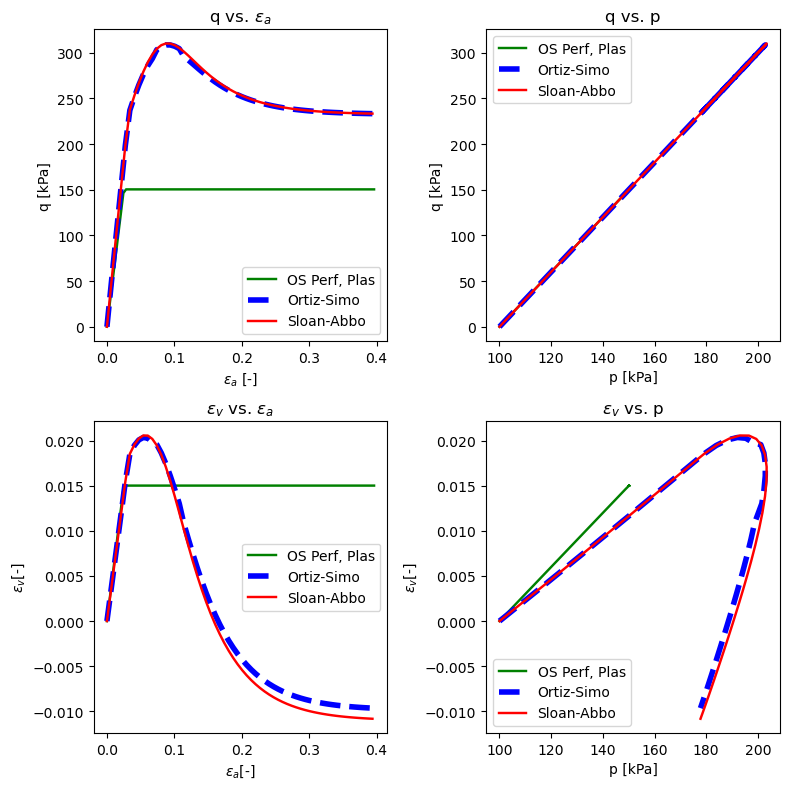

In [33]:
# Generate a figure to plot the MCSS models
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8, 8))

colors = ["green", "blue", "red"]
labels = ["OS Perf, Plas", "Ortiz-Simo", 'Sloan-Abbo']
styles = ["solid", "dashed", "solid"]
line_widths = [1.75, 4, 1.75]

for model, color, label, style, linewidth in zip(models, colors, labels, styles, line_widths):
    model.results.quick_quad_plot(axial_strain_id="stran(1)", compression_pos=True, axs = axs, 
                                  color = color , label=label, legend = True, linestyle = style, linewidth = linewidth)
    
plt.show()

image_name = "Drained_Strain_Controlled_plastic_rate.pdf"
mcss_latex_folder = "/home/jmoore/Documents/Master_Thesis/chapters/3_Constitutive_Modelling/srmc_images"
save_fig_path = os.path.join(mcss_latex_folder, image_name)
fig.savefig(save_fig_path, format = "pdf", bbox_inches = 'tight')

plt.close()